## Clusters con pipeline y GridSearch

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import FunctionTransformer, normalize
#from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import silhouette_score
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling
import numpy as np
from sklearn.cluster import KMeans
import math
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

#### 0. Importamos los datos

In [2]:
os.getcwd()

'c:\\Users\\Ciberseguridad & IA\\Documents\\Tomas\\03 Aprendizaje no supervisado'

In [3]:
file='Mall_Customers.csv'
df = pd.read_csv(file, delimiter=',', low_memory=False)
df.shape
#os.getcwd()
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


##### El set de datos proviene de aquí: https://www.kaggle.com/code/niteshyadav3103/customer-segmentation-using-kmeans-hc-dbscan?select=Mall_Customers.csv



#### 1. Transformamos los datos empleando un pipeline

In [4]:
df_original = df

In [5]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


Analizamos como es la poblacion de clientes de nuestro banco
Para ello vamos a excluir las variables que tiene que ver con interacciones con ventas

In [6]:
df.columns.tolist()

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

El dataset X contiene las variables input de mi analisis cluster

In [7]:
X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [8]:
def tipo_variables(df):
    dtypes = df.dtypes
    categorical_cols = []
    numerical_cols = []
    for col, dtype in dtypes.items():
        if pd.api.types.is_numeric_dtype(dtype):
            numerical_cols.append(col)
        else:
            categorical_cols.append(col)
    return numerical_cols, categorical_cols
    
vbles = tipo_variables(X)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

['Gender']
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [9]:
def MyHotEncoder(X):
    from sklearn.preprocessing import OneHotEncoder
    # Crear un objeto OneHotEncoder
    encoder = OneHotEncoder(sparse_output=False)
    cat_vbles = tipo_variables(X)[1]
    #El parámetro sparse_output=False asegura que la salida sea un array denso 
    #(en lugar de una matriz dispersa), lo cual es más fácil de convertir en un DataFrame de pandas.
    for i in cat_vbles:
        encoded_data = encoder.fit_transform(X[[i]])
        column_names = encoder.get_feature_names_out([i])
        encoded_X=pd.DataFrame(encoded_data, columns=column_names)
        X = pd.concat([X, encoded_X], axis=1)
    X = X.drop(columns=cat_vbles)
    return X

Verificamos si tenemos valores a null. En este ejemplo no hay, si hubiera tendríamos que tratarlos

In [10]:
def quitar_nulos(df):
    df_sin_nulos = df.dropna()
    return df_sin_nulos

Estandarizamos las variables

In [11]:
def normalizar(df):
    df_norm= preprocessing.normalize(df)
    return df_norm

In [12]:
pipeline = Pipeline([
    ('MyHotEncoder', FunctionTransformer(MyHotEncoder)),  # Paso 1: grestina variables categoricas
    ('quitar_nulos', FunctionTransformer(quitar_nulos)),  # Paso 2: quita registros con nulos
    ('normalizar', FunctionTransformer(normalizar))                   # Paso 3: Normalizar
])    

In [13]:
X_norm = pipeline.fit_transform(X)
X_norm[:10]

array([[0.4138265 , 0.32670513, 0.84943334, 0.        , 0.02178034],
       [0.24700755, 0.17643396, 0.9527434 , 0.        , 0.01176226],
       [0.75973718, 0.60778974, 0.22792115, 0.03798686, 0.        ],
       [0.28067571, 0.19525267, 0.93965346, 0.01220329, 0.        ],
       [0.58058136, 0.31838332, 0.74913723, 0.01872843, 0.        ],
       [0.27183291, 0.2100527 , 0.93905914, 0.01235604, 0.        ],
       [0.87885343, 0.45198176, 0.15066059, 0.0251101 , 0.        ],
       [0.23365009, 0.18285659, 0.95491775, 0.0101587 , 0.        ],
       [0.95757323, 0.28427955, 0.04488625, 0.        , 0.01496208],
       [0.37365957, 0.23665106, 0.89678296, 0.01245532, 0.        ]])

#### 2. Determinamos el numero de cluster

Utilizamos el métido K-Means, este método espera un a priori de numero de clusters. Hacemos un primer ejercicio para determinar el numero optimo de clusters 

Hay dos metricas principales para evaluar el modelo kmeans: 

Inertia que es la que tiene pro defecto kmeans y mide los cuadrados de las distancias a los centroiodes

Silhooutte: mide la distancia entre los cluster y la cohesion interna de cada cluster

#### 2.1 Con GridSearch

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, silhouette_score

kmeans = KMeans(random_state=77)


param_grid = {
    'n_clusters': [ 3, 4, 5, 6, 7, 8, 9],  # Probar diferentes valores de clústeres
    'init': ['k-means++', 'random'],  # Métodos de inicialización
    'n_init': [10, 20],  # Número de inicializaciones
    'max_iter': [300, 500]  # Iteraciones máximas
}

# cv indica el nuemmero de grupos que hace para el cross validation

def my_silhouette_scorer(estimator, X, y=None):
    labels = estimator.predict(X)
    return silhouette_score(X, labels) if len(set(labels)) > 1 else float('nan')

    
grid_search = GridSearchCV(
    estimator=kmeans,
    param_grid=param_grid,
    scoring = my_silhouette_scorer,
    cv=None,
    n_jobs=-1,
    verbose=2
)

# si scoring va vacio utiliza la propia metrica score del estimador, en este caso el score del kmeans corresponde con la inertia

# Ejecutar la búsqueda de hiperparámetros
grid_search.fit(X_norm)

# Mejor resultado
best_kmeans = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Mejores parámetros:", best_params)
print("Mejor estimador:", best_kmeans)
print("Mejor puntaje score:", grid_search.best_score_)


#grid_search = GridSearchCV( kmeans, param_grid, cv=2,  scoring=make_scorer(silhouette_scorer), verbose=1)
#grid_search.fit(X_norm)



Fitting 5 folds for each of 56 candidates, totalling 280 fits
Mejores parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4, 'n_init': 10}
Mejor estimador: KMeans(n_clusters=4, n_init=10, random_state=77)
Mejor puntaje score: 0.5792087590891795


#### 2.2 Con coeficiente Silhouette

<Axes: >

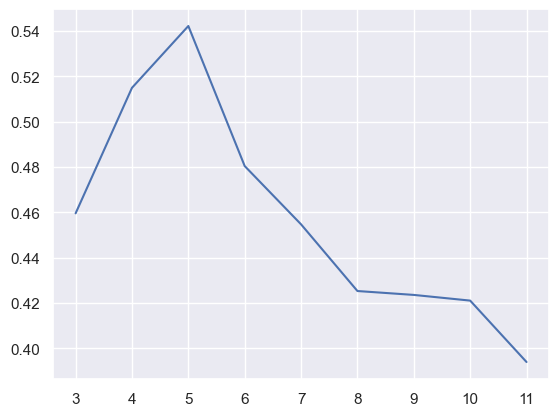

In [15]:
# identificamos el mejor nimero de cluster empleando la metrica silhoutte
K = range(3, 12)
fits = []
score = []


for k in K:
    # train the model for current value of k on training data
    #model = KMeans(n_clusters = k, init='k-means++', n_init=10, max_iter=300, random_state = 77).fit(X_norm)

    model = KMeans(n_clusters = k, init='k-means++', n_init=10, max_iter=300, random_state = 77)
    model.fit(X_norm)
    y_kmeans = model.predict(X_norm)

    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(X_norm, y_kmeans, metric='euclidean'))


sns.lineplot(x = K, y = score)

#### 2.3 Con el método del codo

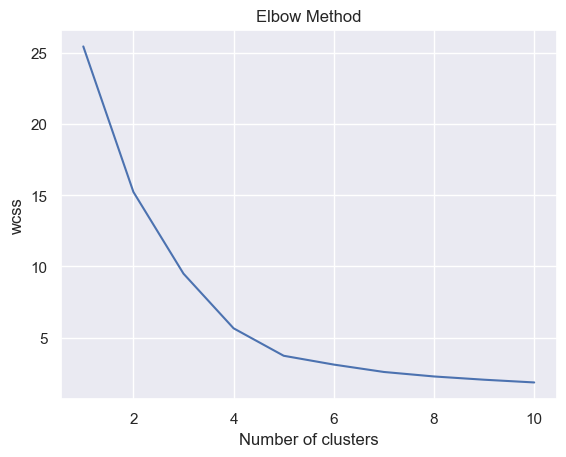

In [16]:
# identificamos el mejor nimero de cluster empleando la metrica inertia
# el metodo de elbow emplea las inertias 
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    km=KMeans(n_clusters=i,init='k-means++', max_iter=300, n_init=10, random_state=77)
    km.fit(X_norm)
    wcss.append(km.inertia_)
plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('wcss')
plt.show()


#### 3. Modelo IK-means

In [17]:
# el k=4 es el que mejor funciona.
# ver como imputar el resultado

kmeans=KMeans(n_clusters=4,init='k-means++', max_iter=300, n_init=10, random_state=77)
kmeans.fit(X_norm)
y_kmeans = kmeans.predict(X_norm)

X['cluster']=y_kmeans
X.head()
X.groupby("cluster").size()
# Analisis descriptivo vs cluster. ver si se puede automatizar algo ... 

cluster
0    78
1    60
2    37
3    25
dtype: int64

#### 4. Descriptivo de los cluster

In [18]:
#Ahora le pego el num de cluster

X_ori2 = pd.merge(df, X[['cluster']], left_index=True, right_index=True)
X_ori2

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,3
2,3,Female,20,16,6,1
3,4,Female,23,16,77,3
4,5,Female,31,17,40,3
...,...,...,...,...,...,...
195,196,Female,35,120,79,0
196,197,Female,45,126,28,2
197,198,Male,32,126,74,0
198,199,Male,32,137,18,2


In [19]:
X_ori2.shape

(200, 6)

In [20]:
X_ori2.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,3
2,3,Female,20,16,6,1
3,4,Female,23,16,77,3
4,5,Female,31,17,40,3
5,6,Female,22,17,76,3
6,7,Female,35,18,6,1
7,8,Female,23,18,94,3
8,9,Male,64,19,3,1
9,10,Female,30,19,72,3


In [21]:
# selecciono las variables continuas para describirlas como son sus medias y medianas. 

print(cat_vbles)
print(num_vbles)

['Gender']
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [22]:
# Construyo la tabla de medias:

table_avg = pd.pivot_table(X_ori2, values=num_vbles, index=['cluster'],
                       aggfunc='mean')
table_avg

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,30.961538,71.730769,66.294872
1,53.516667,44.166667,38.583333
2,40.729730,87.297297,18.054054
3,25.480000,25.480000,75.440000


In [23]:
table_median = pd.pivot_table(X_ori2, values=num_vbles, index=['cluster'],
                       aggfunc='median')
table_median

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,31.0,69.5,61.5
1,52.5,46.5,44.5
2,42.0,81.0,16.0
3,24.0,24.0,76.0


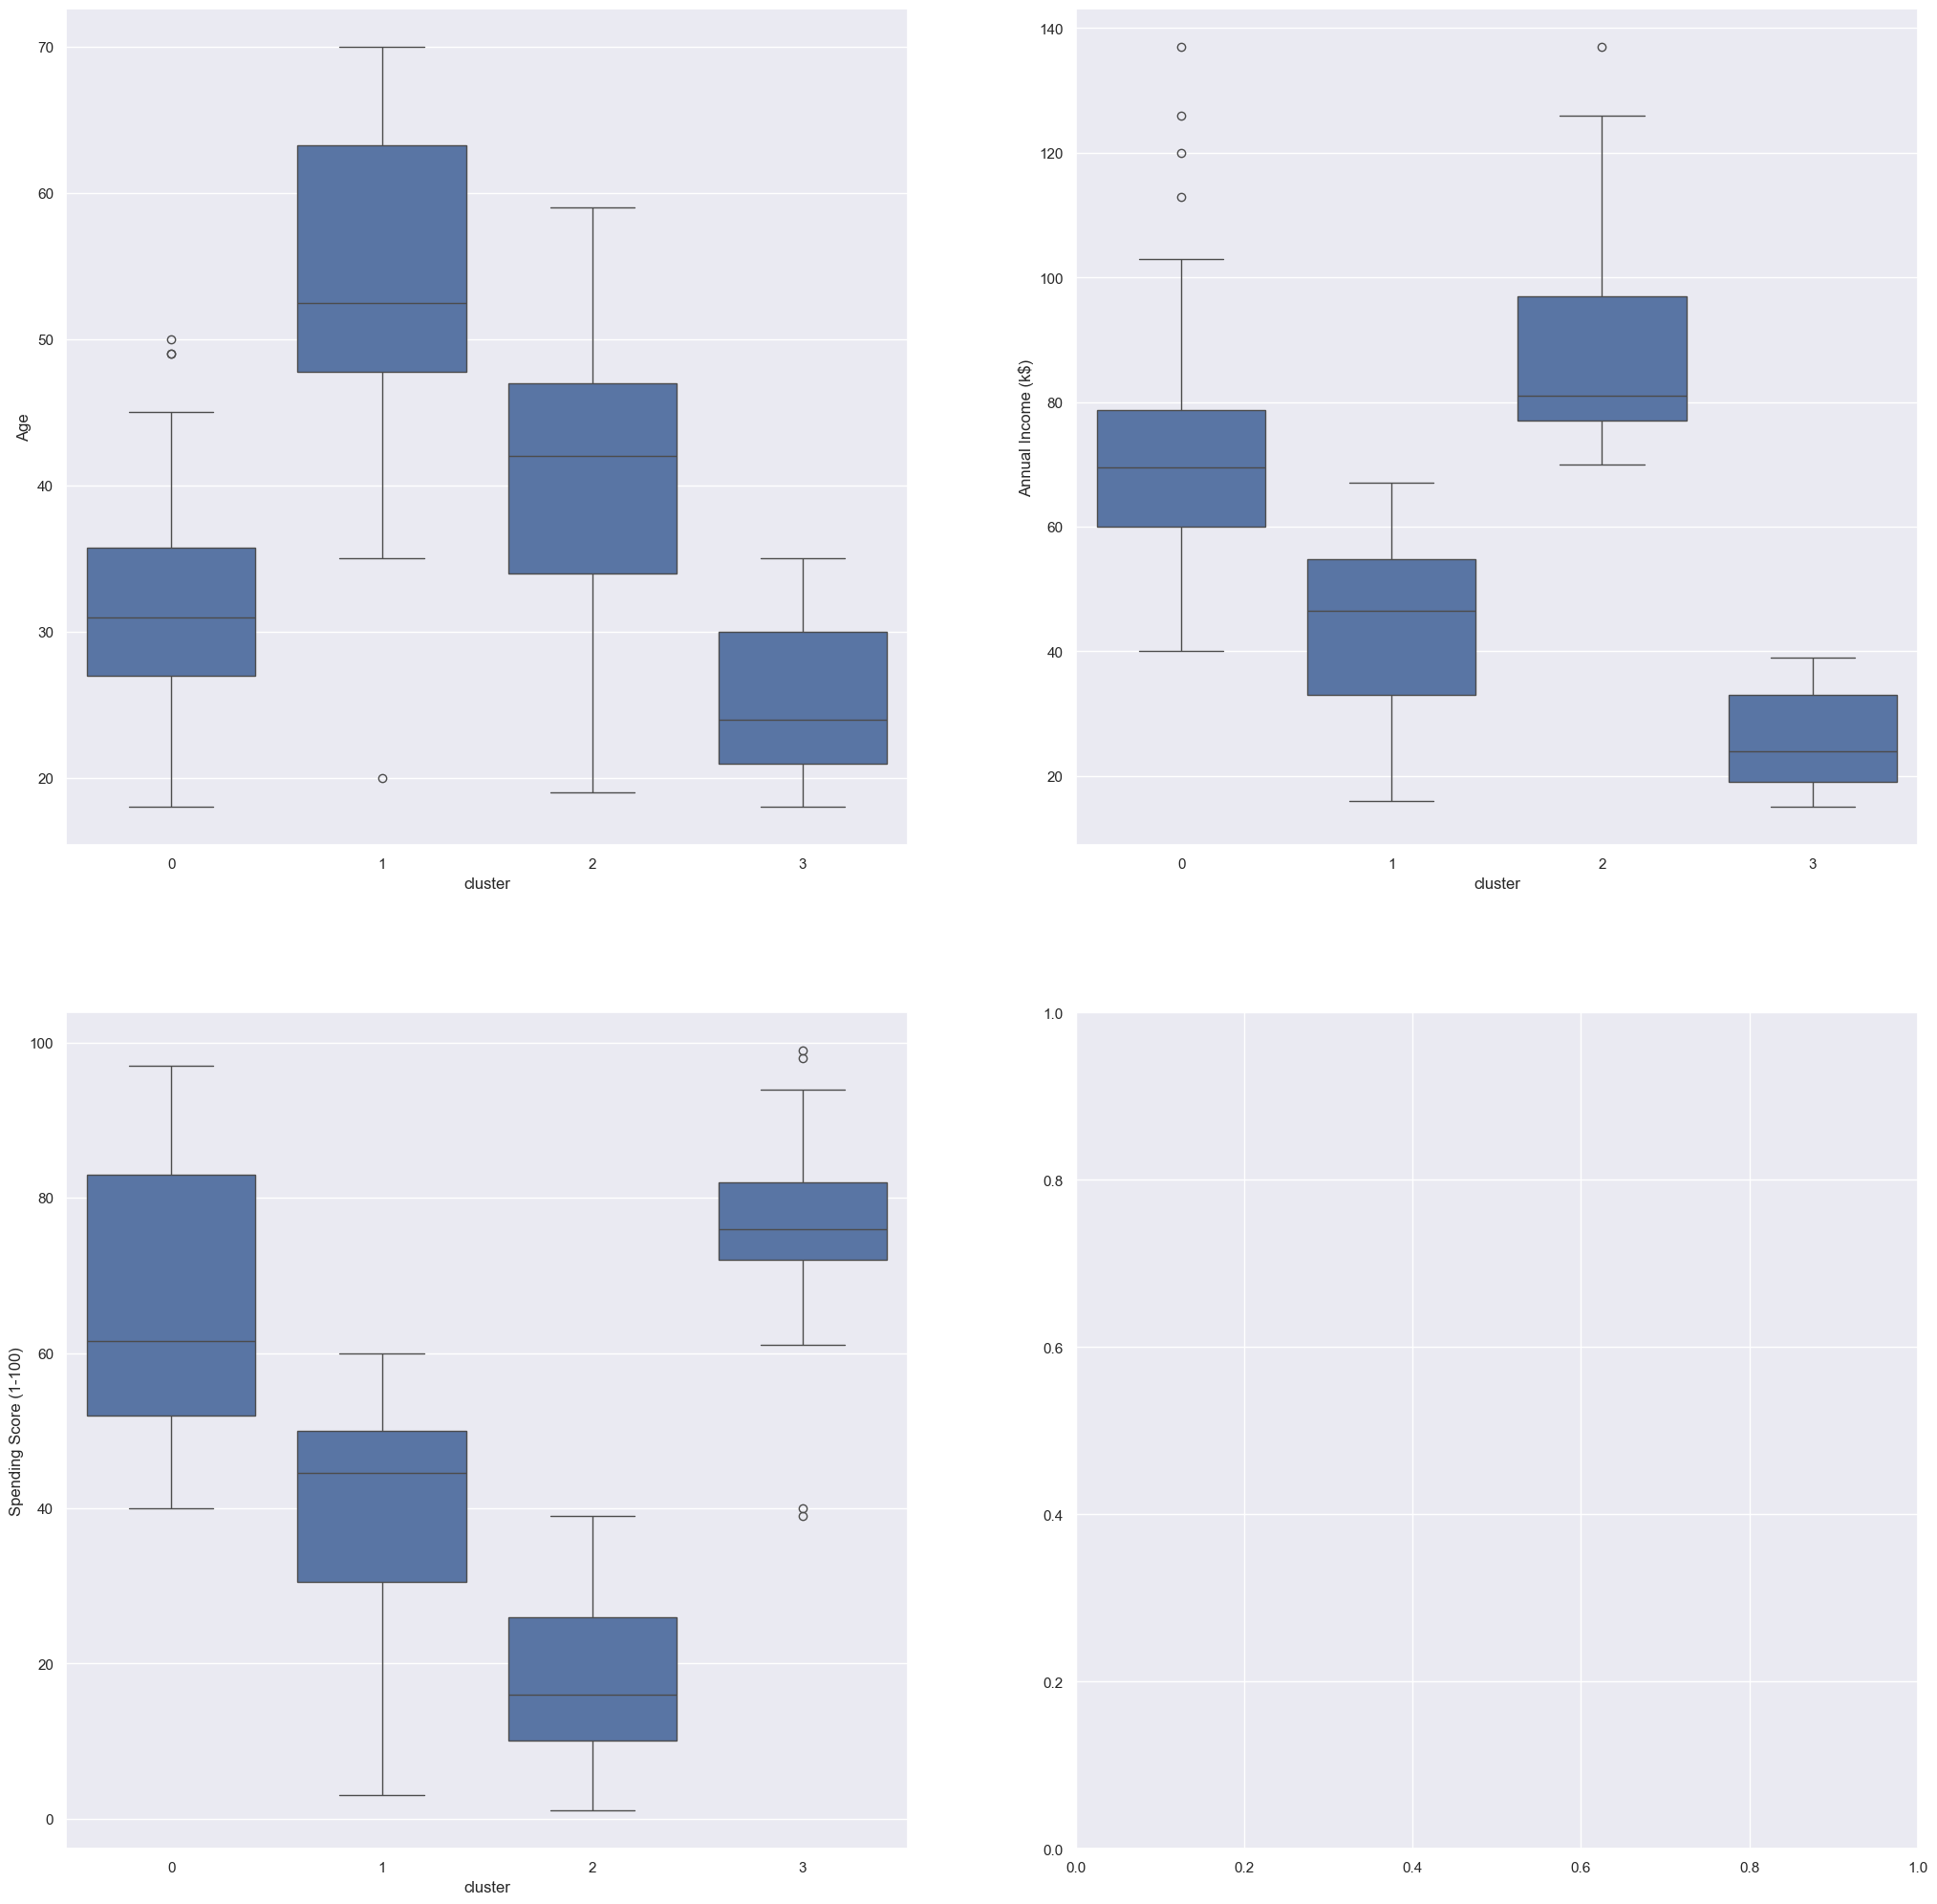

In [24]:

a= math.floor(math.sqrt(len(num_vbles)))+1

fig, axes = plt.subplots(a, a, figsize=(25,25))
axes = axes.flatten()
i = 0
for t in num_vbles:
    ax = sns.boxplot(x='cluster', y=t, data=X_ori2, orient='v', 
    ax=axes[i])
    i +=1

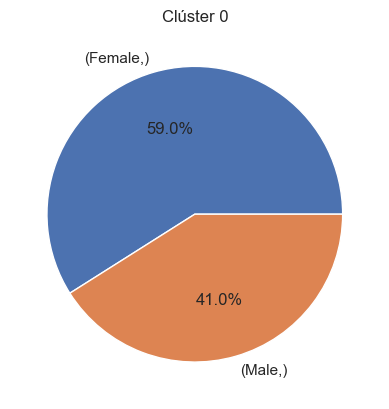

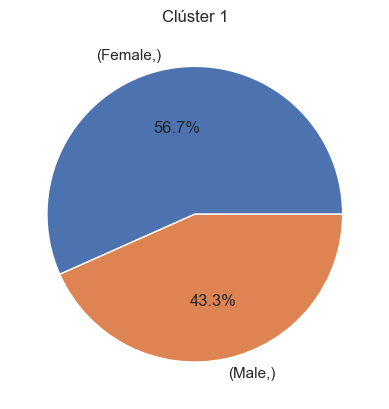

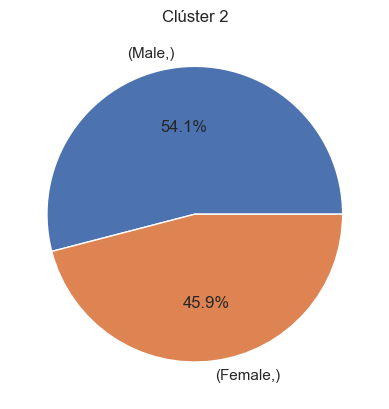

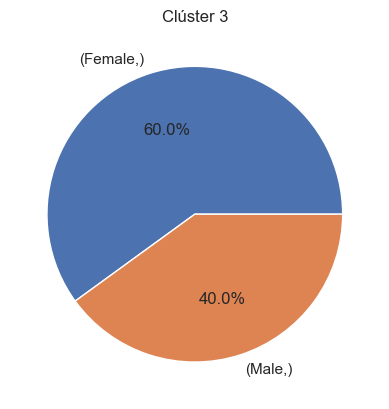

In [25]:
n_clus = X_ori2['cluster'].sort_values().unique()
palette_color = sns.color_palette('bright') 

chars1 = cat_vbles
#fig, ax = plt.subplots(len(chars1), len(n_clus), figsize=(20,20))


if len(chars1) == 1:
     for j in range(len(n_clus)): 
        filtered_data = X_ori2.loc[ X_ori2['cluster'] == j]
        plt.figure() 
        filtered_data[chars1].value_counts().plot(kind='pie' , autopct='%1.1f%%')
        plt.title(f'Clúster {j}')
        plt.show()
else:
    
    k = 0
    i = 0
    j = 0
    fig, ax = plt.subplots(1, 4, figsize=(25,25))
    for i in range(len(chars1)-1):
        for j in range(len(n_clus)-1):
            table = pd.pivot_table(X_ori2.loc[X_ori2['cluster']==n_clus[j]], values='cluster', index=[chars1[i]], aggfunc='count')
            vals = table['cluster'].values
            my_labels = table.index
            title = "Var: "+my_labels.name+"; Cluster: "+str(n_clus[j])
            ax[i,j].pie(vals,
                       labels =  my_labels, 
                        autopct=lambda p: '{:.0f}%'.format(p),
                        startangle=90, shadow = False)
            ax[i,j].set_title(title)
            k+=1
            
            
    
    plt.tight_layout()
    fig.savefig('subplots.png')
    plt.show()

#### 5. Analisis PCA para representar los clusters en dos ejes 

In [26]:
pca = PCA(2)
data = pca.fit_transform(X_norm)
print(data[:10])

[[ 0.41435993  0.14613147]
 [ 0.61792322  0.10022583]
 [-0.33627245  0.28791455]
 [ 0.58868105  0.11606318]
 [ 0.28620908  0.28921568]
 [ 0.58391459  0.10006195]
 [-0.36379301  0.48245188]
 [ 0.62064681  0.0856571 ]
 [-0.39833146  0.65445291]
 [ 0.50704769  0.16665464]]


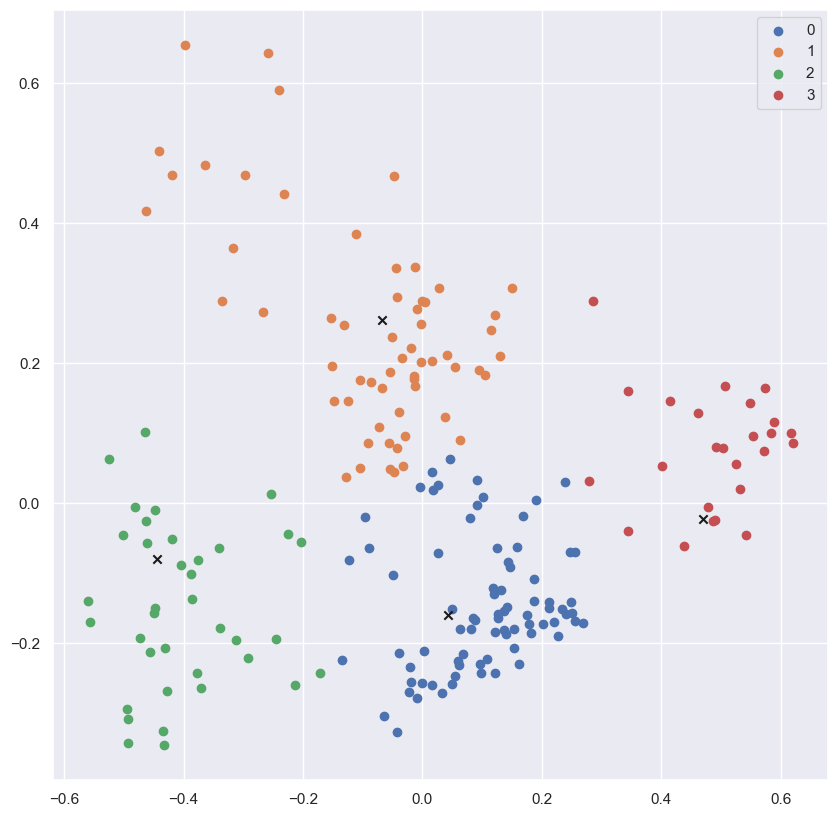

In [27]:
centers = pca.fit_transform(np.array(kmeans.cluster_centers_))
label = y_kmeans
#label = kmeans.fit_predict(data)
# 
plt.figure(figsize=(10,10))
uniq = np.unique(label)
for i in uniq:
   plt.scatter(data[label == i , 0] , data[label == i , 1] , label = i)
plt.scatter(centers[:,0], centers[:,1], marker="x", color='k')

#This is done to find the centroid for each clusters.
plt.legend()
plt.show()